# IRCC Tracker — Local exploratory analysis

Hybrid pipeline:

1. **Validator (regex)** decides which messages are worth LLM extraction.
   - Hashtag path: contains `#پیشرفت_پرونده` AND >=1 canonical label-with-value.
   - Non-hashtag path: contains >=3 canonical labels-with-value.
2. **LLM extraction** on every approved candidate.
3. **Cache (v2 envelope)** records each candidate's outcome by `message_id`,
   so we never re-call the LLM for the same message twice.
4. **Aggregate** the cache into a DataFrame and produce plots focused on
   total citizenship-process duration.

Audience: us, studying the data. Anomalies are flagged in-place rather than
silently filtered. See `CLAUDE.md` for project context, roadmap, and
conventions.

> First-run cost: a few cents on `gpt-4o-mini`. Subsequent runs reuse the
> per-message cache and cost nothing.


In [1]:
import os
import re
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI
from tqdm import tqdm  # plain tqdm (text mode) — renders reliably in VS Code

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Walk up from the notebook's cwd until we find CLAUDE.md (= repo root).
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "CLAUDE.md").exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not locate repo root (CLAUDE.md not found above cwd)")
    REPO_ROOT = REPO_ROOT.parent

load_dotenv(REPO_ROOT / ".env")
if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError(
        f"OPENAI_API_KEY not found. Put it in {REPO_ROOT/'.env'} as OPENAI_API_KEY=sk-..."
    )

# Timeout so a stuck request fails fast instead of hanging silently.
client = OpenAI(timeout=30.0)

# Knob for cheap testing — set to a small int to limit LLM calls per run.
MAX_NEW_EXTRACTIONS = None  # e.g. MAX_NEW_EXTRACTIONS = 5

print(f"Repo root: {REPO_ROOT}")


Repo root: /home/hamid/ircc_tracker


In [2]:
EXPORTS_DIR = REPO_ROOT / "data" / "citizenship"
exports = sorted(p for p in EXPORTS_DIR.glob("ChatExport_*") if p.is_dir())
if not exports:
    raise FileNotFoundError(f"No ChatExport_* directories under {EXPORTS_DIR}")

EXPORT_DIR    = exports[-1]   # lex-sort == chronological since names end in YYYY-MM-DD
RAW_PATH      = EXPORT_DIR / "result.json"
FILTERED_PATH = EXPORT_DIR / "filtered_results.json"
CACHE_DIR     = EXPORT_DIR / "llm_processed_openai"
CSV_PATH      = CACHE_DIR / "processed_data.csv"
CACHE_DIR.mkdir(exist_ok=True)

print(f"Latest export: {EXPORT_DIR.name}")
print(f"Older exports available: {[e.name for e in exports[:-1]]}")


Latest export: ChatExport_2026-04-30
Older exports available: ['ChatExport_2026-03-29']


In [3]:
# Bootstrap: copy cache files from older exports for any message IDs we don't
# already have. Same message ID = same Telegram message = same content, so the
# LLM result is reusable across exports. Saves API spend on the catch-up run.
older_exports = [p for p in exports if p != EXPORT_DIR and (p / "llm_processed_openai").exists()]
copied = 0
skipped = 0
for older in older_exports:
    older_cache = older / "llm_processed_openai"
    for src in older_cache.glob("*.json"):
        if src.name == "processed_data.csv":
            continue
        dst = CACHE_DIR / src.name
        if dst.exists():
            skipped += 1
            continue
        shutil.copy2(src, dst)
        copied += 1
print(f"Bootstrapped {copied} cache files from older exports (skipped {skipped} already present)")
print(f"Cache now contains: {sum(1 for p in CACHE_DIR.glob('*.json'))} files")


Bootstrapped 0 cache files from older exports (skipped 532 already present)
Cache now contains: 551 files


## 1. Load + helpers

Telegram exports messages where `text` is sometimes a string and sometimes a
list of entity dicts. We always normalize via `text_entities` to be safe.


In [4]:
with open(RAW_PATH, encoding="utf-8") as f:
    raw = json.load(f)

def joined_text(msg: dict) -> str:
    """All text from a message, joining string and entity-list forms."""
    text = msg.get("text", "")
    if isinstance(text, list):
        return "".join(t if isinstance(t, str) else t.get("text", "") for t in text)
    return str(text)

def message_plain_text(msg: dict) -> str:
    """Plain-text body only (drops hashtag/link/mention entities)."""
    return "".join(e.get("text", "") for e in msg.get("text_entities", []) if e.get("type") == "plain")

print(f"Total messages in export: {len(raw.get('messages', []))}")


Total messages in export: 21861


## 2. Validator (regex gatekeeper)

The validator decides whether a message is worth sending to the LLM. It is
**not** an extractor — extraction stays the LLM's job. Two paths:

- **Hashtag path**: message contains `#پیشرفت_پرونده` AND >=1 canonical
  label-with-value. The label-with-value rule rejects empty form templates
  (admin posts that show the blank form) which would otherwise pass on the
  hashtag alone.
- **Non-hashtag path**: message contains >=3 canonical labels-with-value.
  Stricter to keep precision high; catches members who post the form without
  the hashtag.

A "label-with-value" is a canonical label followed (within the same line) by
`:` and at least one non-separator character. Anything in
`{":", "：", "-", "–", "—", whitespace}` is treated as a separator and not a
value.


In [5]:
HASHTAG = "#پیشرفت_پرونده"

# Canonical labels from the form template. Confirmed by Hamid 2026-04-30.
# Mix of Farsi and English/Latin since the form mixes both languages.
CANONICAL_LABELS = [
    "نوع اپلیکیشن",
    "تعداد اپلیکنت",
    "شهر محل سکونت",
    "آفیس بررسی پرونده",
    "سابمیت پرونده",
    "تاریخ AOR",
    "تاریخ دعوت به تست",
    "تاریخ تست",
    "تاریخ Ceremony",
    "تاریخ دریافت Certificate",
    "Background Verification",
    "fingerprint",
    "finger print",
]


In [6]:
# Validator algorithm:
#   1. Find every canonical-label occurrence in the text (case-insensitive
#      for the English ones).
#   2. For each unique label, take the slice from end-of-this-label to
#      start-of-the-next-canonical-label (or end of text). This is its
#      "section".
#   3. Within the section, locate the first colon (handles parenthetical
#      label qualifiers like "(آنلاین/کاغذی)" appearing before the colon).
#   4. After the colon, strip any trailing leaked next-item bullet (the very
#      common pattern "\n\n۲-" / "\n2-" that appears when the next label
#      isn't in our canonical set).
#   5. If anything non-separator remains, count it as label-with-value.
#
# This handles values written on the same line *and* values on a following
# line — both are common in this Telegram group's posts.

_LABEL_PAT = re.compile("|".join(re.escape(l) for l in CANONICAL_LABELS), re.IGNORECASE)
_TRAIL_NEXT_ITEM = re.compile(r"\n+\s*[\d۰-۹]+\s*[-–—]\s*$")
_NON_SEPARATOR = re.compile(r"[^\s:：\-–—]")

def _section_value(section: str) -> str | None:
    """Return the candidate value text within a section, or None if no colon."""
    colon = re.search(r"[:：]", section[:200])
    if not colon:
        return None
    value = section[colon.end():]
    # Strip trailing leaked bullets like '\n\n۲-' so they don't masquerade as content.
    value = _TRAIL_NEXT_ITEM.sub("", value)
    return value

def count_labels_with_values(text: str) -> int:
    matches = list(_LABEL_PAT.finditer(text))
    if not matches:
        return 0
    seen = set()
    count = 0
    for i, m in enumerate(matches):
        key = m.group(0).lower()
        if key in seen:
            continue
        section_end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        section = text[m.end():section_end]
        value = _section_value(section)
        if value is None:
            continue
        if _NON_SEPARATOR.search(value):
            seen.add(key)
            count += 1
    return count

def validate(msg: dict) -> dict:
    full  = joined_text(msg)
    plain = message_plain_text(msg)
    has_hashtag = HASHTAG in full
    n = count_labels_with_values(plain)
    if has_hashtag and n >= 1:
        return {"passed": True, "source": "hashtag", "label_hits": n}
    if (not has_hashtag) and n >= 3:
        return {"passed": True, "source": "heuristic", "label_hits": n}
    return {"passed": False, "source": None, "label_hits": n}


In [7]:
# Run the validator over the entire export.
candidates = []        # list of (message_dict, validation_result)
hashtag_total = 0
hashtag_rejected = 0   # has hashtag but 0 labels-with-value (e.g. empty templates)
heuristic_total = 0

for msg in raw.get("messages", []):
    if msg.get("type") != "message":   # skip "service" entries (joins, migrations, ...)
        continue
    if not msg.get("text_entities"):
        continue
    v = validate(msg)
    has_hashtag = HASHTAG in joined_text(msg)
    if has_hashtag:
        hashtag_total += 1
        if not v["passed"]:
            hashtag_rejected += 1
    if v["passed"]:
        if v["source"] == "heuristic":
            heuristic_total += 1
        candidates.append((msg, v))

# Persist the filtered set for inspection (mirrors the original Colab artifact).
with open(FILTERED_PATH, "w", encoding="utf-8") as f:
    json.dump([m for m, _ in candidates], f, ensure_ascii=False, indent=2)

# Funnel
total_msgs = len(raw.get("messages", []))
existing_cache_ids = {int(p.stem) for p in CACHE_DIR.glob("*.json") if p.stem.isdigit()}
to_extract = [(m, v) for (m, v) in candidates if m["id"] not in existing_cache_ids]

print(f"Total messages in export:                    {total_msgs}")
print(f"  with #پیشرفت_پرونده hashtag:                {hashtag_total}")
print(f"    rejected (no label-with-value, e.g. blank template): {hashtag_rejected}")
print(f"  hashtag-less but heuristic-passed:         {heuristic_total}")
print(f"Total candidates passing validator:          {len(candidates)}")
print(f"Already in cache (any status):               {len(candidates) - len(to_extract)}")
print(f"Need new LLM call:                           {len(to_extract)}")
print(f"Saved candidates to: {FILTERED_PATH.relative_to(REPO_ROOT)}")


Total messages in export:                    21861
  with #پیشرفت_پرونده hashtag:                559
    rejected (no label-with-value, e.g. blank template): 124
  hashtag-less but heuristic-passed:         5
Total candidates passing validator:          440
Already in cache (any status):               440
Need new LLM call:                           0
Saved candidates to: data/citizenship/ChatExport_2026-04-30/filtered_results.json


## 3. Migrate cache to v3 envelope

Cache evolves over time. The migration step routes any record found on disk
to the current schema:

- **v1** (flat 18-field dict, original Colab format) → wrap into v3 with
  `primary` populated and `review.status="pending"`.
- **v2** (single `extracted` block, no reviewer) → unwrap into v3 with the
  same fields under `primary`, and `review.status="pending"` so the reviewer
  pass picks it up.
- **v3** → skip.

`raw_text` for v1 records is recovered from any export's
`filtered_results.json` we can find on disk.


In [8]:
SCHEMA_VERSION = 3
PRIMARY_MODEL = "gpt-4o-mini"
REVIEW_MODEL  = "gpt-4o"

EXTRACTED_FIELDS = [
    "app_type", "applicant_count", "city", "visa_office",
    "submission_date", "aor_date", "interview_date", "fingerprint_date",
    "passport_stamps_request_date", "bg_verification_date", "test_invite_date",
    "test_date", "test_tracker_date", "other_requirements_date",
    "oath_in_progress_date", "ceremony_invite_date", "ceremony_date",
    "certificate_received_date", "certificate_type", "notes",
    "inferred_dates",   # v3: comma-separated list of date-field names whose
                        # year was inferred (no explicit year in the source)
]

DATE_FIELDS = [
    "submission_date", "aor_date", "interview_date", "fingerprint_date",
    "passport_stamps_request_date", "bg_verification_date", "test_invite_date",
    "test_date", "test_tracker_date", "other_requirements_date",
    "oath_in_progress_date", "ceremony_invite_date", "ceremony_date",
    "certificate_received_date",
]

# Lookup table for raw_text by message_id, sourced from current filtered set
# AND from any older exports' filtered_results.json files we can find. Older
# data lets us migrate cache files copied via the bootstrap step.
raw_text_by_id = {}
for export in exports:
    fp = export / "filtered_results.json"
    if not fp.exists():
        continue
    for m in json.load(open(fp, encoding="utf-8")):
        mid = m.get("id")
        if mid is None or mid in raw_text_by_id:
            continue
        raw_text_by_id[mid] = message_plain_text(m)

def _make_v3(mid, extracted, source, validator, llm_status, llm_error, raw_text):
    """Wrap a single primary extraction into a v3 envelope with pending review."""
    if extracted is not None:
        # Add the new v3 field with a default if missing.
        extracted = {k: extracted.get(k) for k in EXTRACTED_FIELDS}
    return {
        "message_id": mid,
        "schema_version": SCHEMA_VERSION,
        "source": source,
        "validator": validator,
        "primary": {
            "model": PRIMARY_MODEL,
            "status": llm_status,
            "error": llm_error,
            "extracted": extracted,
        },
        "review": {
            "model": REVIEW_MODEL,
            "status": "pending" if llm_status == "ok" else "skipped",
            "error": None,
            "extracted": None,
            "review_changes": None,
        },
        "extracted": extracted,  # working copy: review.extracted overrides this when the reviewer runs
        "raw_text": raw_text,
    }

migrated_v1 = migrated_v2 = skipped = 0
for path in CACHE_DIR.glob("*.json"):
    if path.name == "processed_data.csv":
        continue
    try:
        rec = json.load(open(path, encoding="utf-8"))
    except json.JSONDecodeError:
        print(f"  [skip] corrupt: {path.name}")
        continue

    sv = rec.get("schema_version")
    if sv == SCHEMA_VERSION:
        skipped += 1
        continue

    mid = rec.get("message_id") or int(path.stem)

    if sv == 2:
        # v2 → v3: lift extracted into primary block, mark review pending
        new_rec = _make_v3(
            mid=mid,
            extracted=rec.get("extracted"),
            source=rec.get("source", "hashtag"),
            validator=rec.get("validator") or {"migrated_from_v2": True},
            llm_status=rec.get("llm_status", "ok"),
            llm_error=rec.get("llm_error"),
            raw_text=rec.get("raw_text") or raw_text_by_id.get(mid, ""),
        )
        migrated_v2 += 1
    else:
        # v1 (flat dict) → v3
        flat_extracted = {k: rec.get(k) for k in EXTRACTED_FIELDS}
        new_rec = _make_v3(
            mid=mid,
            extracted=flat_extracted,
            source="hashtag",
            validator={"migrated_from_v1": True},
            llm_status="ok",
            llm_error=None,
            raw_text=raw_text_by_id.get(mid, ""),
        )
        migrated_v1 += 1

    with open(path, "w", encoding="utf-8") as f:
        json.dump(new_rec, f, ensure_ascii=False, indent=2)

print(f"Migrated v1 -> v{SCHEMA_VERSION}: {migrated_v1}")
print(f"Migrated v2 -> v{SCHEMA_VERSION}: {migrated_v2}")
print(f"Already at v{SCHEMA_VERSION} (skipped): {skipped}")


Migrated v1 -> v3: 0
Migrated v2 -> v3: 0
Already at v3 (skipped): 551


## 4. Primary extraction (gpt-4o-mini)

Every validator-approved candidate without a cache file is sent through the
primary extractor. The result is written into the v3 envelope's `primary`
block regardless of outcome (`ok` / `error` / `empty`), so failures are not
retried indefinitely.

To force re-extraction of a single message, delete its `<id>.json` from the
cache directory.

The prompt has two load-bearing constraints:

- **Rule 0** (scalars only). Earlier extractions hit a real LLM-output bug
  where multi-applicant test_dates came back as
  `{"applicant_1": "...", "applicant_2": "..."}` and crashed downstream
  parsing. Don't relax this.
- **Year inference**. Most users only write the year on their submission
  date and abbreviate the rest as month/day. The prompt explicitly tells the
  LLM to anchor missing years to the most recent earlier date with an
  explicit year, advancing by one year when monotonicity would otherwise
  break. Without this rule, ~6% of extractions land in the LLM's training-cutoff year (2023) regardless of the actual timeline.


In [9]:
EXTRACTION_PROMPT = """
You are an expert data extraction and standardization assistant. I will provide you with a Farsi message containing user data from a Canadian immigration/citizenship progress form.

Your task is to extract the information, STANDARDIZE the formatting, and return ONLY a valid JSON object.

CRITICAL STANDARDIZATION RULES:
0. EVERY field MUST be a single scalar value: a string, an integer, or null. NEVER return objects, arrays, or nested structures. If multiple values apply (e.g., a fingerprint request date AND a fingerprint completion date, or different dates for different applicants), pick the most representative one — for "fingerprint_date" prefer the request/submission date — or merge them into a single human-readable string. The downstream pipeline assumes scalars; objects/arrays will be discarded.

1. Dates: You MUST convert ALL dates (whether written in Farsi, English, or mixed formats) to the standard ISO format: `YYYY-MM-DD`.
   - Example: "۱۰ نوامبر ۲۰۲۵" -> "2025-11-10"
   - Example: "02/April/2022" -> "2022-04-02"
   - Example: "۴ سپتامبر ۲۰۲۵" -> "2025-09-04"
   - If a date is missing or not provided, return null.

1a. YEAR INFERENCE — applies whenever the user writes a date without an explicit year.
   - The form's date fields are MONOTONIC in real time. The expected order is:
       submission_date <= aor_date <= interview_date <= fingerprint_date
       <= passport_stamps_request_date <= bg_verification_date <= test_invite_date
       <= test_date <= test_tracker_date <= other_requirements_date
       <= oath_in_progress_date <= ceremony_invite_date <= ceremony_date
       <= certificate_received_date.
   - When a date in the message lacks a year, anchor it to the year of the most recent EARLIER date in this monotonic sequence that DID have an explicit year in the message.
   - If anchoring would place the new date BEFORE that earlier date in calendar order, advance the year by one (and keep advancing if needed) so the sequence stays monotonic.
   - DO NOT default a missing year to your training-data year, the current year, or any fixed default. The anchor MUST come from the user's text.
   - If the user writes ABSOLUTELY NO years anywhere in the message (no anchor exists), still infer using monotonicity starting from a plausible base, AND list every inferred field in the `inferred_dates` output below.
   - When a date's year is genuinely ambiguous (e.g. user wrote "29 January" with no year and the rest of the post is in late autumn so it could be the *next* January), pick the chronologically-consistent option AND add that field name to `inferred_dates`.

2. app_type: Must be strictly "Online" or "Paper".
   - Translate Farsi equivalents (e.g., "آنلاین" -> "Online", "کاغذی" -> "Paper").

3. applicant_count: Must be an INTEGER representing the total number of people.
   - "Single", "تکی", "یک نفر", "One person" -> 1
   - "دو نفر", "زوج", "Two" -> 2
   - "Family (3)", "۳ نفر خانوادگی", "3" -> 3
   - "Family 4", "خانوادگی- ٤ نفر" -> 4
   - If the user only says "Family" or "خانوادگی" without specifying a number, return null to prevent bad data.

4. city & visa_office: Translate Farsi city/office names to standard English proper nouns.
   - Example: "ونکوور" -> "Vancouver"
   - Example: "سیدنی" -> "Sydney"
   - Example: "ریچموند هیل" -> "Richmond Hill"

5. certificate_type: Must be strictly "Electronic" or "Paper". Translate from Farsi (e.g., "الکترونیکی" -> "Electronic").

6. inferred_dates: A comma-separated string listing the field names of any DATE fields whose year you had to infer (because the user did not write the year explicitly for that date). Example: "aor_date,bg_verification_date,test_invite_date". If no dates required inference, return an empty string "". This MUST be a string, not a list.

Keys to extract and standardize:
- "app_type": String ("Online" or "Paper")
- "applicant_count": Integer
- "city": String (English)
- "visa_office": String (English)
- "submission_date": String (YYYY-MM-DD)
- "aor_date": String (YYYY-MM-DD)
- "interview_date": String (YYYY-MM-DD)
- "fingerprint_date": String (YYYY-MM-DD)
- "passport_stamps_request_date": String (YYYY-MM-DD)
- "bg_verification_date": String (YYYY-MM-DD)
- "test_invite_date": String (YYYY-MM-DD)
- "test_date": String (YYYY-MM-DD)
- "test_tracker_date": String (YYYY-MM-DD)
- "other_requirements_date": String (YYYY-MM-DD)
- "oath_in_progress_date": String (YYYY-MM-DD)
- "ceremony_invite_date": String (YYYY-MM-DD)
- "ceremony_date": String (YYYY-MM-DD)
- "certificate_received_date": String (YYYY-MM-DD)
- "certificate_type": String ("Electronic" or "Paper")
- "notes": String (Keep the exact original Farsi text for this field)
- "inferred_dates": String (comma-separated field names, possibly empty)

Here is the Farsi text:
{farsi_text}
"""

SYSTEM_PROMPT = (
    "You are a highly accurate data extraction bot. "
    "You only output valid JSON and strictly follow data formatting rules."
)

def extract_one(farsi_text: str):
    """Returns (status, payload, error). status in {"ok", "error", "empty"}."""
    try:
        resp = client.chat.completions.create(
            model=PRIMARY_MODEL,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": EXTRACTION_PROMPT.format(farsi_text=farsi_text)},
            ],
            temperature=0.0,
        )
    except Exception as e:
        return "error", None, str(e)
    try:
        payload = json.loads(resp.choices[0].message.content)
    except (json.JSONDecodeError, IndexError, AttributeError) as e:
        return "empty", None, f"could not parse JSON: {e}"
    return "ok", payload, None


In [10]:
print(f"starting primary extraction on {len(to_extract)} candidates "
      f"(MAX_NEW_EXTRACTIONS={MAX_NEW_EXTRACTIONS})...", flush=True)

todo = to_extract if MAX_NEW_EXTRACTIONS is None else to_extract[:MAX_NEW_EXTRACTIONS]
n_ok = n_err = n_empty = 0

for msg, v in tqdm(todo, desc="extracting"):
    mid = msg["id"]
    text = message_plain_text(msg)
    status, payload, err = extract_one(text)
    extracted = (
        {k: (payload.get(k) if payload else None) for k in EXTRACTED_FIELDS}
        if payload else None
    )

    envelope = {
        "message_id": mid,
        "schema_version": SCHEMA_VERSION,
        "source": v["source"],
        "validator": {"label_hits": v["label_hits"]},
        "primary": {
            "model": PRIMARY_MODEL,
            "status": status,
            "error": err,
            "extracted": extracted,
        },
        "review": {
            "model": REVIEW_MODEL,
            "status": "pending" if status == "ok" else "skipped",
            "error": None,
            "extracted": None,
            "review_changes": None,
        },
        "extracted": extracted,  # working copy; reviewer pass overwrites if it succeeds
        "raw_text": text,
    }
    with open(CACHE_DIR / f"{mid}.json", "w", encoding="utf-8") as f:
        json.dump(envelope, f, ensure_ascii=False, indent=2)

    if   status == "ok":    n_ok    += 1
    elif status == "error": n_err   += 1
    else:                   n_empty += 1

print(f"done. ok={n_ok}  error={n_err}  empty={n_empty}")
print(f"Cache total: {sum(1 for p in CACHE_DIR.glob('*.json'))} files")


starting primary extraction on 0 candidates (MAX_NEW_EXTRACTIONS=None)...


extracting: 0it [00:00, ?it/s]

extracting: 0it [00:00, ?it/s]

done. ok=0  error=0  empty=0
Cache total: 551 files


## 5. Reviewer pass (gpt-4o)

Every record where `review.status == "pending"` is sent through a stronger
model that sees the raw Farsi text *and* the primary extraction. Its job is
to catch year-inference mistakes, swapped fields, and any other systematic
errors the primary missed.

The reviewer can either return the corrected JSON (overwriting the working
`extracted` block) or signal "no changes" (we keep `primary.extracted`).
Either way we record the pass in `review`. Only `extracted` (top-level) is
read by aggregation.

To force re-review of a record, set its `review.status` back to `"pending"`
in the cache file and re-run this cell.


In [11]:
REVIEW_PROMPT = """
You are reviewing a structured-extraction result for a Farsi-language Canadian-citizenship progress form. A junior extractor has already produced a JSON. Your job is to find and fix any errors — especially year-inference mistakes — and return the corrected JSON.

The form's date fields are MONOTONIC in real time:
  submission_date <= aor_date <= interview_date <= fingerprint_date
  <= passport_stamps_request_date <= bg_verification_date <= test_invite_date
  <= test_date <= test_tracker_date <= other_requirements_date
  <= oath_in_progress_date <= ceremony_invite_date <= ceremony_date
  <= certificate_received_date.

Common mistakes to look for:
- Years defaulted to 2023 (or another fixed year) when the user wrote month/day only. Fix by anchoring to the most recent earlier date in the chain that has an explicit year in the source text, then advancing by 1 year as needed to preserve monotonicity.
- Date placed in the wrong field (e.g. test_date written under aor_date because both lines mention "tracker").
- City vs visa_office swapped.
- applicant_count returning 1 when the user wrote "Family" without a number (should be null).

Output rules:
- Return ONLY a valid JSON object using EXACTLY the same keys as the input. No new keys, no missing keys.
- Every value must be a SINGLE SCALAR (string, integer, or null). No objects, no arrays. The "inferred_dates" key is a comma-separated string.
- If you change a date's year, ALSO add that field's name to "inferred_dates".
- Add one extra key "_review_changes" (string): a short human-readable description of what you changed, or "no changes" if you didn't change anything.

Here is the original Farsi text:
{farsi_text}

Here is the junior extractor's JSON:
{primary_json}
"""

REVIEW_SYSTEM = (
    "You are a senior data-quality reviewer. Output strict JSON only, "
    "preserving the input schema exactly and fixing year-inference mistakes."
)

import time
def review_one(farsi_text: str, primary_extracted: dict, max_retries: int = 5):
    """Returns (status, payload, error, review_changes). Retries on 429."""
    delay = 2.0
    last_err = None
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=REVIEW_MODEL,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": REVIEW_SYSTEM},
                    {"role": "user",   "content": REVIEW_PROMPT.format(
                        farsi_text=farsi_text,
                        primary_json=json.dumps(primary_extracted, ensure_ascii=False, indent=2),
                    )},
                ],
                temperature=0.0,
            )
            break
        except Exception as e:
            last_err = str(e)
            # Backoff on rate-limit / transient errors; bail on auth/etc.
            if "429" in last_err or "rate limit" in last_err.lower() or "timeout" in last_err.lower():
                time.sleep(delay)
                delay = min(delay * 2, 30.0)
                continue
            return "error", None, last_err, None
    else:
        return "error", None, last_err, None
    try:
        payload = json.loads(resp.choices[0].message.content)
    except (json.JSONDecodeError, IndexError, AttributeError) as e:
        return "empty", None, f"could not parse JSON: {e}", None
    review_changes = payload.pop("_review_changes", None)
    extracted = {k: payload.get(k) for k in EXTRACTED_FIELDS}
    return "ok", extracted, None, review_changes

# Find all v3 records where review hasn't successfully completed yet.
# We retry "error" rows automatically on each run (most are 429s).
RETRY_REVIEW_STATUSES = {"pending", "error"}

pending = []
for path in sorted(CACHE_DIR.glob("*.json")):
    if path.name == "processed_data.csv":
        continue
    try:
        rec = json.load(open(path, encoding="utf-8"))
    except json.JSONDecodeError:
        continue
    if rec.get("schema_version") != SCHEMA_VERSION:
        continue
    if (rec.get("review") or {}).get("status") in RETRY_REVIEW_STATUSES:
        pending.append(path)

print(f"reviewer pass on {len(pending)} pending/errored record(s) "
      f"(model={REVIEW_MODEL}, MAX_NEW_REVIEWS={MAX_NEW_EXTRACTIONS})...", flush=True)

todo = pending if MAX_NEW_EXTRACTIONS is None else pending[:MAX_NEW_EXTRACTIONS]
n_ok = n_err = n_empty = n_changed = 0

for path in tqdm(todo, desc="reviewing"):
    rec = json.load(open(path, encoding="utf-8"))
    primary_extracted = (rec.get("primary") or {}).get("extracted") or {}
    raw_text = rec.get("raw_text", "")

    status, extracted, err, review_changes = review_one(raw_text, primary_extracted)

    rec["review"] = {
        "model": REVIEW_MODEL,
        "status": status,
        "error": err,
        "extracted": extracted,
        "review_changes": review_changes,
    }
    if status == "ok" and extracted is not None:
        rec["extracted"] = extracted
        if extracted != primary_extracted:
            n_changed += 1
    else:
        rec["extracted"] = primary_extracted

    with open(path, "w", encoding="utf-8") as f:
        json.dump(rec, f, ensure_ascii=False, indent=2)

    if   status == "ok":    n_ok    += 1
    elif status == "error": n_err   += 1
    else:                   n_empty += 1

print(f"done. ok={n_ok}  error={n_err}  empty={n_empty}")
print(f"Reviewer changed {n_changed}/{n_ok} extractions (vs primary)")


reviewer pass on 0 pending/errored record(s) (model=gpt-4o, MAX_NEW_REVIEWS=None)...


reviewing: 0it [00:00, ?it/s]

reviewing: 0it [00:00, ?it/s]

done. ok=0  error=0  empty=0
Reviewer changed 0/0 extractions (vs primary)


## 6. Aggregate cache → DataFrame

Reads every v3 envelope and flattens to a row using the top-level `extracted`
(which is `review.extracted` when the reviewer succeeded, otherwise
`primary.extracted`). Records with no successful primary stay in `all_df`
for diagnosis but are excluded from the headline `df`.

`df` keeps rows where the primary succeeded AND at least one core date
(`submission_date`, `aor_date`, `ceremony_date`, `certificate_received_date`)
is non-null.


In [12]:
def _coerce_scalar(v):
    """Flatten dict/list LLM artifacts to a scalar string. Rule 0 of the
    prompt forbids objects/arrays, but occasionally a stray one slips
    through — we recover by picking the first usable scalar inside rather
    than crashing the aggregation."""
    if v is None or isinstance(v, (str, int, float, bool)):
        return v
    items = list(v.values()) if isinstance(v, dict) else (v if isinstance(v, list) else [])
    for x in items:
        if isinstance(x, str) and x:
            return x
        if isinstance(x, (int, float)) and not isinstance(x, bool):
            return x
    return None

records = []
for p in sorted(CACHE_DIR.glob("*.json")):
    try:
        rec = json.load(open(p, encoding="utf-8"))
    except json.JSONDecodeError:
        print(f"  [skip] corrupt: {p.name}")
        continue
    if rec.get("schema_version") != SCHEMA_VERSION:
        print(f"  [skip] pre-v{SCHEMA_VERSION}: {p.name}  (re-run migration cell)")
        continue

    primary = rec.get("primary") or {}
    review  = rec.get("review")  or {}
    extracted = rec.get("extracted") or {}
    messy = any(isinstance(extracted.get(f), (dict, list)) for f in EXTRACTED_FIELDS)

    primary_extracted = primary.get("extracted") or {}
    review_changed = (
        review.get("status") == "ok"
        and review.get("extracted") is not None
        and review.get("extracted") != primary_extracted
    )

    flat = {
        "message_id":       rec.get("message_id"),
        "source":           rec.get("source"),
        "primary_status":   primary.get("status"),
        "primary_error":    primary.get("error"),
        "review_status":    review.get("status"),
        "review_error":     review.get("error"),
        "review_changed":   bool(review_changed),
        "review_changes":   review.get("review_changes"),
        "label_hits":       (rec.get("validator") or {}).get("label_hits"),
        "extraction_messy": messy,
    }
    for f in EXTRACTED_FIELDS:
        flat[f] = _coerce_scalar(extracted.get(f))
    flat["raw_text"] = rec.get("raw_text", "")
    records.append(flat)

all_df = pd.DataFrame(records)

CORE_DATES = ["submission_date", "aor_date", "ceremony_date", "certificate_received_date"]
ok_mask    = all_df["primary_status"] == "ok"
core_mask  = (all_df[CORE_DATES].notna().any(axis=1)
              if all(c in all_df.columns for c in CORE_DATES)
              else pd.Series(False, index=all_df.index))
df = all_df.loc[ok_mask & core_mask].copy()

all_df.to_csv(CSV_PATH, index=False, encoding="utf-8")
print(f"Cache rows total:                      {len(all_df)}")
print(f"  primary_status=ok:                   {ok_mask.sum()}")
print(f"  + at least one core date present:    {(ok_mask & core_mask).sum()}  <- `df`")
print(f"  ok but no core dates (mostly noise): {(ok_mask & ~core_mask).sum()}")
print(f"  primary_status != ok (errors/empty): {(~ok_mask).sum()}")
print(f"  rows the reviewer changed:           {all_df['review_changed'].sum()}")
print(f"  rows still pending review:           {(all_df['review_status'] == 'pending').sum()}")
print(f"  rows where review failed:            {all_df['review_status'].isin(['error','empty']).sum()}")
if "extraction_messy" in all_df.columns:
    print(f"  rows with messy LLM output (dict/list, coerced): {all_df['extraction_messy'].sum()}")
print(f"Saved full cache table -> {CSV_PATH.relative_to(REPO_ROOT)}")
df.head()


Cache rows total:                      551
  primary_status=ok:                   551
  + at least one core date present:    422  <- `df`
  ok but no core dates (mostly noise): 129
  primary_status != ok (errors/empty): 0
  rows the reviewer changed:           458
  rows still pending review:           0
  rows where review failed:            0
  rows with messy LLM output (dict/list, coerced): 1
Saved full cache table -> data/citizenship/ChatExport_2026-04-30/llm_processed_openai/processed_data.csv


,message_id,source,primary_status,primary_error,review_status,review_error,review_changed,review_changes,label_hits,extraction_messy,app_type,applicant_count,city,visa_office,submission_date,aor_date,interview_date,fingerprint_date,passport_stamps_request_date,bg_verification_date,test_invite_date,test_date,test_tracker_date,other_requirements_date,oath_in_progress_date,ceremony_invite_date,ceremony_date,certificate_received_date,certificate_type,notes,inferred_dates,raw_text
1,33594,hashtag,ok,None,ok,None,False,no changes,NaN,False,Online,1.0,None,None,2022-04-02,2022-04-27,None,None,None,2022-10-28,2022-11-14,2022-11-26,2022-12-08,2023-01-10,None,None,2023-03-20,2023-03-24,None,دعوت نشدم درخواست فینگر پرینت نداشتم,None,\n\n۱- نوع اپلیکیشن (آنلاین/کاغذی): \nانلاین\...
3,33642,hashtag,ok,None,ok,None,False,no changes,NaN,False,Online,1.0,None,None,2023-03-09,2023-03-23,None,None,None,2023-05-11,None,None,None,None,None,None,None,None,None,۱- نوع اپلیکیشن (آنلاین/کاغذی): آنلاین\n\n۲-تع...,None,\n\n۱- نوع اپلیکیشن (آنلاین/کاغذی): آنلاین\n\...
4,33655,hashtag,ok,None,ok,None,False,no changes,NaN,False,Paper,NaN,None,None,2023-01-09,2023-02-23,None,None,None,2023-04-11,2023-05-16,2023-05-19,None,None,None,None,None,None,None,۱- نوع اپلیکیشن (آنلاین/کاغذی): کاغذی\n\n۲-تع...,None,\n\n۱- نوع اپلیکیشن (آنلاین/کاغذی): کاغذی\n\...
5,33716,hashtag,ok,None,ok,None,True,Inferred test_tracker_date as 2023-03-02 based...,NaN,False,Online,2.0,None,None,2022-11-22,2022-12-22,None,None,None,2023-02-02,2023-02-13,2023-02-22,2023-03-02,2023-03-16,None,2023-04-11,2023-05-08,2023-05-29,None,ما دو هفته بعد سرمونی که سرتیفیکیت رو دریافت ن...,test_tracker_date,\n\n۱- نوع اپلیکیشن (آنلاین/کاغذی): آنلاین\n\...
8,33874,hashtag,ok,None,ok,None,True,"Corrected bg_verification_date to 2022-12-31, ...",NaN,False,Paper,NaN,None,None,2022-10-15,2022-11-30,None,None,None,2022-12-31,2023-02-28,2023-03-21,2023-04-04,None,None,None,None,None,None,تا اینجای کار ۸ ماه و هنوز از سرمونی خبری نیست.,"bg_verification_date,test_invite_date,test_tra...",\n\n۱- نوع اپلیکیشن (آنلاین/کاغذی): کاغذی \n\...


## 7. Total process duration

Headline metric: **how long does the citizenship process take, end-to-end**?

- **Start** = `submission_date` if present, else `aor_date`.
- **End**   = `certificate_received_date` if present, else `ceremony_date`.


In [13]:
DATE_COLS = [
    "submission_date", "aor_date", "interview_date", "fingerprint_date",
    "passport_stamps_request_date", "bg_verification_date", "test_invite_date",
    "test_date", "test_tracker_date", "other_requirements_date",
    "oath_in_progress_date", "ceremony_invite_date", "ceremony_date",
    "certificate_received_date",
]
for c in DATE_COLS:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

df["start_date"]      = df["submission_date"].fillna(df["aor_date"])
df["end_date"]        = df["certificate_received_date"].fillna(df["ceremony_date"])
df["duration_days"]   = (df["end_date"] - df["start_date"]).dt.days
df["submission_year"] = df["start_date"].dt.year

complete_mask = df["duration_days"].notna()
print(f"Records in df:                  {len(df)}")
print(f"Records with both start & end:  {complete_mask.sum()}")
if complete_mask.any():
    print(f"Median duration (raw, all):     {df['duration_days'].median():.0f} days")
    print(f"Mean duration   (raw, all):     {df['duration_days'].mean():.0f} days")


Records in df:                  422
Records with both start & end:  267


Median duration (raw, all):     166 days
Mean duration   (raw, all):     191 days


## 8. Outlier flagging

Flag rows with `duration_days < 0` or `> 5*365`. **Flag, never silently drop.**
The flagged rows surface below with raw `notes` and all key dates so we can
diagnose whether the cause is LLM misextraction (year flip, swapped fields) or
sparse user input.


In [14]:
LOW, HIGH = 0, 5 * 365  # 0 days .. 5 years

df["is_outlier"] = df["duration_days"].notna() & ~df["duration_days"].between(LOW, HIGH)

n_complete = df["duration_days"].notna().sum()
n_outliers = df["is_outlier"].sum()
clean = df.loc[df["duration_days"].between(LOW, HIGH)].copy()

print(f"Complete pairs:                       {n_complete}")
print(f"Outliers (<{LOW} or >{HIGH} days, flagged): {n_outliers}")
if len(clean):
    print(f"Clean cohort:                         {len(clean)}  "
          f"(median {clean['duration_days'].median():.0f} d, "
          f"mean {clean['duration_days'].mean():.0f} d)")


Complete pairs:                       267
Outliers (<0 or >1825 days, flagged): 2
Clean cohort:                         265  (median 167 d, mean 194 d)


In [15]:
flagged_view = (
    df.loc[df["is_outlier"]]
      .sort_values("duration_days")
      [["message_id", "source", "duration_days",
        "submission_date", "aor_date",
        "ceremony_date", "certificate_received_date",
        "notes"]]
)
print(f"{len(flagged_view)} flagged rows")
flagged_view


2 flagged rows


,message_id,source,duration_days,submission_date,aor_date,ceremony_date,certificate_received_date,notes
318,47647,hashtag,-238.0,2023-11-04,2023-11-14,2023-03-11,NaT,
345,49524,hashtag,-189.0,NaT,2023-11-14,2023-05-09,2023-05-09,


## 9. Plots

Slices that map to the eventual Streamlit dashboard cohort filters: overall,
application type, submission-year cohort, city, visa office. **Sample size is
shown alongside every median** — small-N slices are easy to misread.


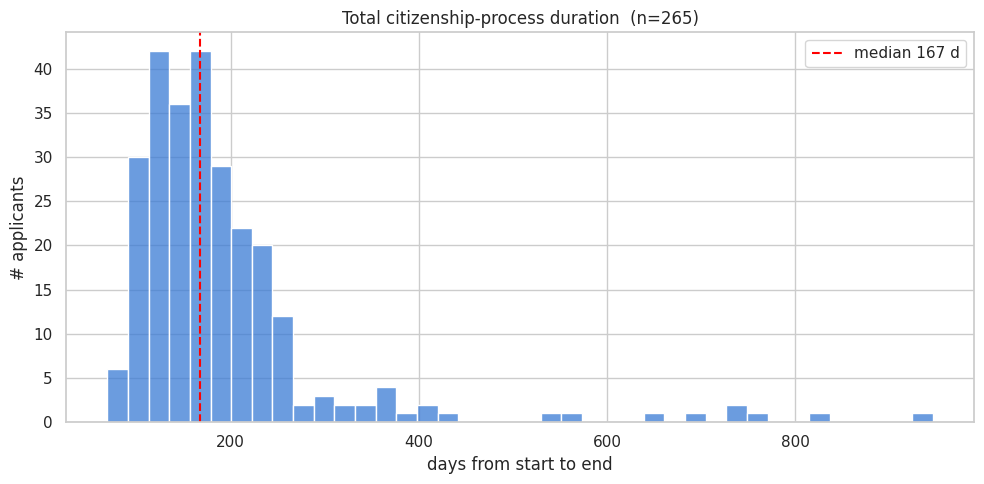

In [16]:
if len(clean):
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(clean["duration_days"], bins=40, ax=ax, color="#3a7bd5")
    median = clean["duration_days"].median()
    ax.axvline(median, color="red", linestyle="--", label=f"median {median:.0f} d")
    ax.set_title(f"Total citizenship-process duration  (n={len(clean)})")
    ax.set_xlabel("days from start to end")
    ax.set_ylabel("# applicants")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("clean cohort is empty — no plot")


In [17]:
def median_by(col, min_n=3):
    if col not in clean.columns or clean[col].notna().sum() == 0:
        return pd.DataFrame(columns=["median_days", "mean_days", "n"])
    g = clean.groupby(col)["duration_days"].agg(["median", "mean", "count"])
    g.columns = ["median_days", "mean_days", "n"]
    return g[g["n"] >= min_n].sort_values("median_days")


          median_days   mean_days    n
app_type                              
Online          165.5  190.746032  252
Paper           176.0  248.666667   12


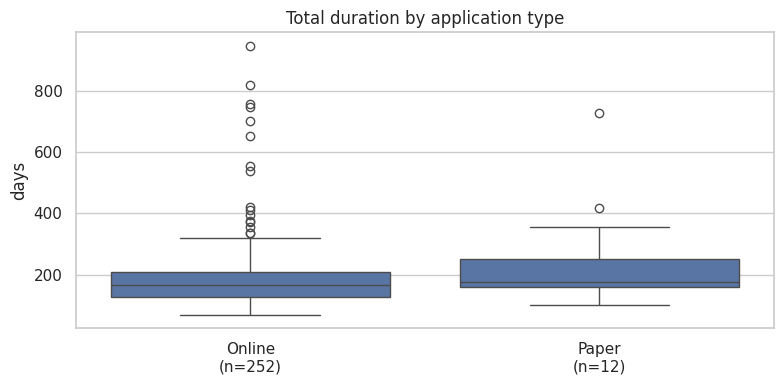

In [18]:
print(median_by("app_type", min_n=1))

if "app_type" in clean.columns and clean["app_type"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=clean, x="app_type", y="duration_days", ax=ax)
    counts = clean["app_type"].value_counts()
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels([f"{lbl.get_text()}\n(n={counts.get(lbl.get_text(), 0)})"
                        for lbl in ax.get_xticklabels()])
    ax.set_title("Total duration by application type")
    ax.set_ylabel("days")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


                 median_days   mean_days    n
submission_year                              
2023.0                 147.0  185.069767  129
2024.0                 149.0  182.951220   41
2025.0                 188.0  203.507042   71
2022.0                 205.0  227.304348   23


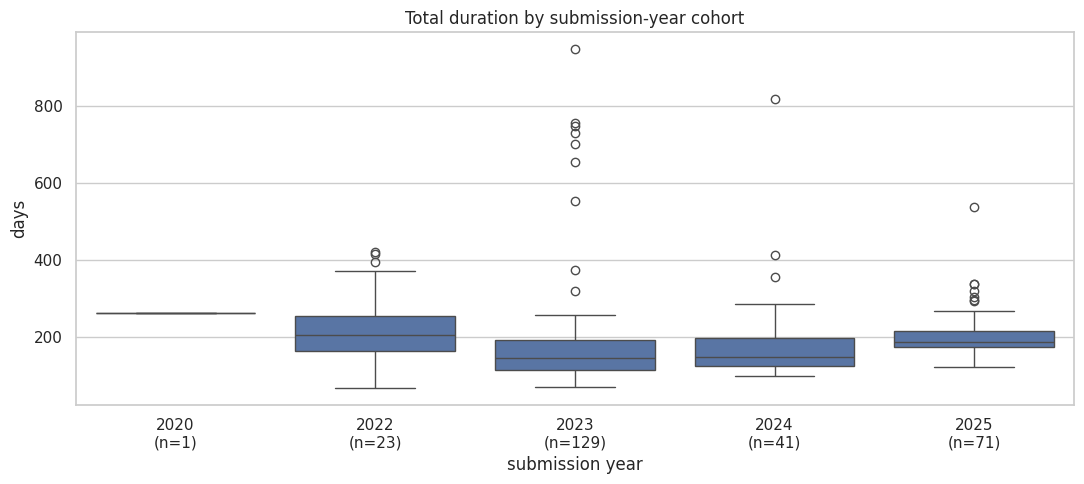

In [19]:
year_stats = median_by("submission_year", min_n=3)
print(year_stats)

years_present = sorted(clean["submission_year"].dropna().unique()) if "submission_year" in clean.columns else []
if years_present:
    counts = clean["submission_year"].value_counts()
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=clean, x="submission_year", y="duration_days",
                order=years_present, ax=ax)
    ax.set_xticks(range(len(years_present)))
    ax.set_xticklabels([f"{int(y)}\n(n={counts.get(y, 0)})" for y in years_present])
    ax.set_title("Total duration by submission-year cohort")
    ax.set_xlabel("submission year")
    ax.set_ylabel("days")
    plt.tight_layout()
    plt.show()


               median_days   mean_days   n
city                                      
Calgary              135.5  181.600000  10
Saskatoon            137.0  197.800000   5
Guelph               148.0  190.000000   3
Montreal             158.0  167.040000  25
Toronto              162.0  190.383562  73
Ottawa               163.0  173.533333  15
Richmond Hill        172.5  170.250000   4
Edmonton             174.5  172.500000   4
Mississauga          188.0  168.666667   3
Vancouver            190.0  206.701754  57
London               256.5  246.500000   4


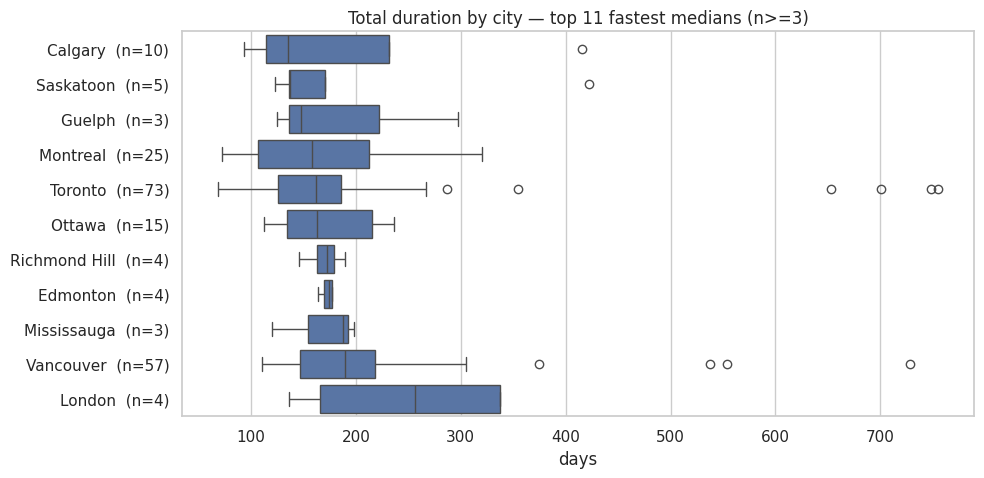

In [20]:
TOP_N, MIN_N = 12, 3

city_stats = median_by("city", min_n=MIN_N).head(TOP_N)
print(city_stats)

if not city_stats.empty:
    order = city_stats.index.tolist()
    sub = clean[clean["city"].isin(order)]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(order))))
    sns.boxplot(data=sub, y="city", x="duration_days", order=order, ax=ax)
    labels = [f"{c}  (n={int(city_stats.loc[c, 'n'])})" for c in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(labels)
    ax.set_title(f"Total duration by city — top {len(order)} fastest medians (n>={MIN_N})")
    ax.set_xlabel("days")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


               median_days   mean_days   n
visa_office                               
Montreal             107.0  143.818182  11
Calgary              126.0  132.200000   5
Mississauga          134.5  161.312500  16
Scarborough          140.5  201.045455  44
Surrey               147.0  171.600000   5
Niagara              147.5  175.500000  14
SCR                  158.0  149.666667   3
Niagara Falls        158.0  180.800000   5
Vancouver            166.5  206.294118  34
Sydney               177.0  177.583333  24


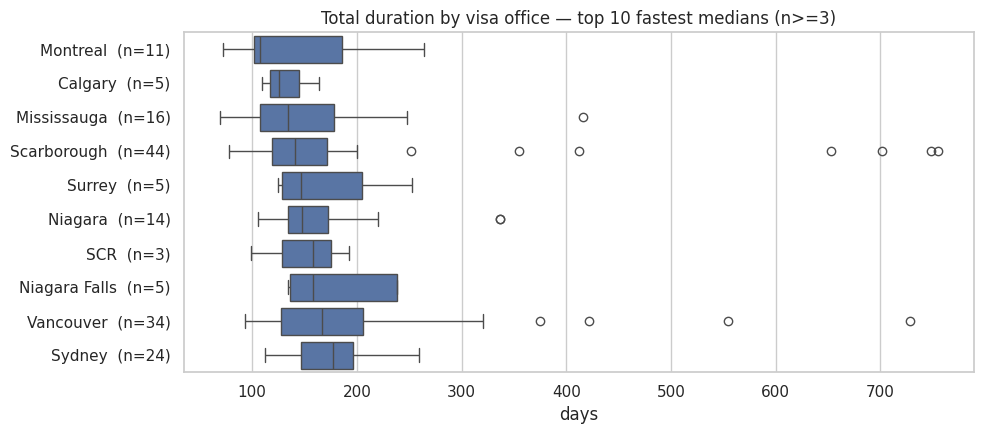

In [21]:
office_stats = median_by("visa_office", min_n=MIN_N).head(TOP_N)
print(office_stats)

if not office_stats.empty:
    order = office_stats.index.tolist()
    sub = clean[clean["visa_office"].isin(order)]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(order))))
    sns.boxplot(data=sub, y="visa_office", x="duration_days", order=order, ax=ax)
    labels = [f"{o}  (n={int(office_stats.loc[o, 'n'])})" for o in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(labels)
    ax.set_title(f"Total duration by visa office — top {len(order)} fastest medians (n>={MIN_N})")
    ax.set_xlabel("days")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


## 9. Emit `analytics.json` for the website

Pre-computed cohort summaries the static frontend at `irccmonitor.ca` reads
to render its hero number, filter pills, and map. The pipeline owns
aggregation; the frontend just plots.

Layout (kept flat and small; entire file is sub-100 KB):

```
{
  "as_of": "<today>",
  "n_total": int,
  "min_n_for_display": 3,           # frontend should warn when n is below this
  "global":     {"median_days": ..., "n": ..., "p25": ..., "p75": ..., "mean": ...},
  "by_city":    { "<city>":   {"median_days": ..., "n": ..., ...}, ... },
  "by_year":    { "<year>":   {"median_days": ..., "n": ..., ...}, ... },
  "by_combo":   { "city=Toronto|year=2024": {...}, ... },   # sparse: only cells with n>=1
  "city_geo":   { "<city>":   {"lat": ..., "lng": ..., "province": "<2-letter>"}, ... }
}
```

Cells with `n < min_n_for_display` are still emitted (for completeness and
client-side sanity checks); the frontend decides how to surface them.


In [22]:
import datetime as _dt

# Hand-curated city centroids. Add entries here as new cities appear in the
# data. Lat/lng only; the frontend handles all display logic.
CITY_GEO = {
    "Toronto":       {"lat": 43.6532, "lng": -79.3832, "province": "ON"},
    "Vancouver":     {"lat": 49.2827, "lng": -123.1207, "province": "BC"},
    "Montreal":      {"lat": 45.5017, "lng": -73.5673, "province": "QC"},
    "Calgary":       {"lat": 51.0447, "lng": -114.0719, "province": "AB"},
    "Edmonton":      {"lat": 53.5461, "lng": -113.4938, "province": "AB"},
    "Ottawa":        {"lat": 45.4215, "lng": -75.6972, "province": "ON"},
    "Mississauga":   {"lat": 43.5890, "lng": -79.6441, "province": "ON"},
    "Saskatoon":     {"lat": 52.1332, "lng": -106.6700, "province": "SK"},
    "Guelph":        {"lat": 43.5448, "lng": -80.2482, "province": "ON"},
    "Richmond Hill": {"lat": 43.8828, "lng": -79.4403, "province": "ON"},
    "London":        {"lat": 42.9849, "lng": -81.2453, "province": "ON"},
    "Winnipeg":      {"lat": 49.8951, "lng": -97.1384, "province": "MB"},
    "Halifax":       {"lat": 44.6488, "lng": -63.5752, "province": "NS"},
    "Quebec City":   {"lat": 46.8139, "lng": -71.2080, "province": "QC"},
    "Hamilton":      {"lat": 43.2557, "lng": -79.8711, "province": "ON"},
    "Kitchener":     {"lat": 43.4516, "lng": -80.4925, "province": "ON"},
    "Waterloo":      {"lat": 43.4643, "lng": -80.5204, "province": "ON"},
    "Burnaby":       {"lat": 49.2488, "lng": -122.9805, "province": "BC"},
    "Surrey":        {"lat": 49.1913, "lng": -122.8490, "province": "BC"},
    "Langley":       {"lat": 49.1044, "lng": -122.6603, "province": "BC"},
    "Kelowna":       {"lat": 49.8880, "lng": -119.4960, "province": "BC"},
    "Victoria":      {"lat": 48.4284, "lng": -123.3656, "province": "BC"},
    "Markham":       {"lat": 43.8561, "lng": -79.3370, "province": "ON"},
    "Vaughan":       {"lat": 43.8361, "lng": -79.4983, "province": "ON"},
    "Oakville":      {"lat": 43.4675, "lng": -79.6877, "province": "ON"},
    "Burlington":    {"lat": 43.3255, "lng": -79.7990, "province": "ON"},
    "Sydney":        {"lat": 46.1351, "lng": -60.1831, "province": "NS"},
    "Scarborough":   {"lat": 43.7764, "lng": -79.2318, "province": "ON"},
    "Niagara":       {"lat": 43.1594, "lng": -79.2469, "province": "ON"},
    "Niagara Falls": {"lat": 43.0962, "lng": -79.0377, "province": "ON"},
}

# 7 milestones in chronological order, mapped to date columns on `clean`.
# Display labels live in the frontend i18n; the JSON is language-neutral.
MILESTONE_KEYS = [
    "submission_date",
    "aor_date",
    "bg_verification_date",
    "test_invite_date",
    "test_date",
    "ceremony_date",
    "certificate_received_date",
]

# `clean` is the in-range cohort: primary_status==ok, at least one core date,
# and 0 <= total duration <= 5*365 days. Outliers are flagged but excluded
# from the public-facing dataset.
records = []
for _, row in clean.iterrows():
    def _date(col):
        v = row.get(col)
        if pd.isna(v):
            return None
        if hasattr(v, "isoformat"):
            return v.date().isoformat() if hasattr(v, "date") else v.isoformat()
        return str(v)
    rec = {
        "city":             row.get("city") if isinstance(row.get("city"), str) else None,
        "year":             int(row["submission_year"]) if pd.notna(row.get("submission_year")) else None,
        "app_type":         row.get("app_type") if row.get("app_type") in ("Online", "Paper") else None,
        "applicant_count":  int(row["applicant_count"]) if pd.notna(row.get("applicant_count")) else None,
        "visa_office":      row.get("visa_office") if isinstance(row.get("visa_office"), str) else None,
        "certificate_type": row.get("certificate_type") if row.get("certificate_type") in ("Electronic", "Paper") else None,
        # Dates in milestone-index order. Null where the user did not share it.
        "dates":            [_date(k) for k in MILESTONE_KEYS],
    }
    records.append(rec)

# Distinct option lists for sidebar dropdowns. Filtered to a minimum count
# so the UI doesn't surface low-signal options. The frontend can still apply
# filters that match zero records — the empty-state UI handles that.
def _option_list(field, min_n=3):
    counts = {}
    for r in records:
        v = r.get(field)
        if v is None or v == "":
            continue
        counts[v] = counts.get(v, 0) + 1
    return sorted([k for k, n in counts.items() if n >= min_n])

analytics = {
    "as_of":             _dt.date.today().isoformat(),
    "n_total":           len(records),
    "min_n_for_display": 3,
    "milestone_keys":    MILESTONE_KEYS,
    "city_geo":          {c: CITY_GEO[c] for c in sorted({r["city"] for r in records if r["city"]}) if c in CITY_GEO},
    "options": {
        "city":             _option_list("city"),
        "year":             [str(y) for y in sorted({r["year"] for r in records if r["year"] is not None})],
        "app_type":         _option_list("app_type", min_n=1),
        "applicant_count":  sorted({r["applicant_count"] for r in records if r["applicant_count"] is not None}),
        "visa_office":      _option_list("visa_office"),
        "certificate_type": _option_list("certificate_type", min_n=1),
    },
    "records": records,
}

seen_cities = sorted({r["city"] for r in records if r["city"]})
missing_geo = [c for c in seen_cities if c not in CITY_GEO]

ANALYTICS_PATH = REPO_ROOT / "web" / "public" / "analytics.json"
ANALYTICS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(ANALYTICS_PATH, "w", encoding="utf-8") as f:
    json.dump(analytics, f, ensure_ascii=False, separators=(",", ":"))

print(f"wrote {ANALYTICS_PATH.relative_to(REPO_ROOT)}  "
      f"({ANALYTICS_PATH.stat().st_size:,} bytes)")
print(f"  records:    {len(records)}")
print(f"  cities:     {len(seen_cities)}  ({len(analytics['city_geo'])} with geo)")
print(f"  filterable options:")
for k, vs in analytics["options"].items():
    print(f"    {k:<18}  {len(vs):>3}  {vs[:6]}{'...' if len(vs) > 6 else ''}")
if missing_geo:
    print(f"  WARNING: cities in data but missing from CITY_GEO: {missing_geo}")


wrote web/public/analytics.json  (59,968 bytes)
  records:    265
  cities:     37  (20 with geo)
  filterable options:
    city                 11  ['Calgary', 'Edmonton', 'Guelph', 'London', 'Mississauga', 'Montreal']...
    year                  5  ['2020', '2022', '2023', '2024', '2025']
    app_type              2  ['Online', 'Paper']
    applicant_count       4  [1, 2, 3, 4]
    visa_office          10  ['Calgary', 'Mississauga', 'Montreal', 'Niagara', 'Niagara Falls', 'SCR']...
    certificate_type      2  ['Electronic', 'Paper']


## Next steps

- Skim the flagged rows above. If a pattern emerges (consistent year flip,
  wrong field mapping for a particular phrasing), the fix is in the prompt
  **not** the data — update `EXTRACTION_PROMPT` and delete the affected
  `<id>.json` files to force re-extraction.
- Skim `review_changes` strings on the rows where the reviewer changed
  primary's output — that's the cheapest signal for whether the primary
  prompt needs further tightening.
- Review heuristic-source rows (`source == "heuristic"`) separately to make
  sure the keyword combination isn't pulling in non-form messages. Tighten
  `CANONICAL_LABELS` or raise the threshold if so.
- Once the analytics shape is stable, lift `validate`, `extract_one`,
  `review_one`, and the duration logic out of the notebook into
  `src/ircc_tracker/` so the future CLI and Streamlit dashboard share the
  same code path. Tracked in `CLAUDE.md`.
